# Train LogisticRegression (5-Fold CV)
Loads `X_2D.npy` and trains LogisticRegression using 5-Fold Cross Validation.

In [1]:
import numpy as np
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [2]:
X_train = np.load('../dataset/X_train_2D.npy')
y_train = np.load('../dataset/y_train.npy')
X_test = np.load('../dataset/X_test_2D.npy')
y_test = np.load('../dataset/y_test.npy')
print('X_train shape:', X_train.shape, 'X_test shape:', X_test.shape)


X_train shape: (46606, 140) X_test shape: (10027, 140)


In [3]:
start_time = time.time()
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
end_time = time.time()
print(f"Training Time: {end_time - start_time:.2f} seconds")


Training Time: 11.93 seconds


Test Accuracy: 86.59%

Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79      1302
           1       0.97      0.91      0.94      7610
           2       0.46      0.79      0.58      1115

    accuracy                           0.87     10027
   macro avg       0.78      0.80      0.77     10027
weighted avg       0.91      0.87      0.88     10027



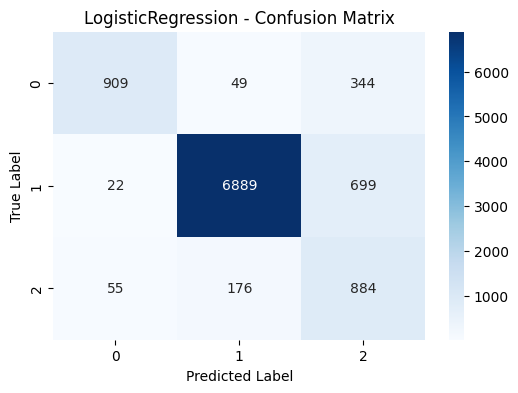

Model saved!


In [4]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")
print('\nTest Classification Report:')
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('LogisticRegression - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
joblib.dump(model, '../models/logisticregression.pkl')
print('Model saved!')